# 금속 다축 피로 수명 예측 — Transformer Encoder 실습

**이전 노트북(SimpleRNN)과 짝을 이루는 비교 실습.**
데이터 전처리는 동일하게 진행하고, 모델만 Transformer encoder로 교체

학습 목표
1. Transformer encoder의 핵심 구성요소(Multi-Head Self-Attention, Position Encoding, Feed-Forward, Residual)를 이해하고 직접 구현한다

2. **동일한 데이터/전처리/평가 절차**에서 SimpleRNN과 Transformer의 성능을 비교한다

3. attention 메커니즘이 시계열의 어느 부분에 집중하는지 관찰한다

4. 두 모델의 파라미터 수, 학습 시간, 성능을 종합적으로 비교한다

## 0. 환경 준비

In [1]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Google Drive 마운트

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2~8. 데이터 로딩 및 전처리 (RNN 노트북과 동일)> **중요**: 이 셀들은 RNN 노트북과 완전히 동일하다. 공정한 비교를 위해서다.

In [4]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 본인 환경에 맞게 수정
ZIP_PATH = '/content/drive/MyDrive/archives_rnn.zip'
EXTRACT_TO = '/content/data'

if not os.path.exists(EXTRACT_TO):
    !unzip -q "$ZIP_PATH" -d $EXTRACT_TO
    print('압축 해제 완료')
else:
    print('이미 풀려있음')

# 풀린 폴더 구조 확인
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/  ({len(files)} files)')

압축 해제 완료
data/  (0 files)
  A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/  (3 files)
    All data_Strain/  (914 files)
    All data_Stress/  (253 files)


In [5]:
# 실제 데이터 구조에 맞게 직접 경로 지정
# data/
# └── A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/
#     ├── All data_Strain/                    ← 변형률 제어 시계열 CSV 폴더
#     ├── All data_Stress/                    ← 응력 제어 시계열 CSV 폴더
#     ├── data_all_strain-controlled.csv      ← 변형률 제어 요약 (라벨 + 물성)
#     ├── data_all_stress-controlled.csv      ← 응력 제어 요약 (라벨 + 물성)
#     └── Specific information of the materials.xlsx

# 압축이 한 단계 더 들어가 있을 수 있으니 실제 경로 확인
!ls $EXTRACT_TO

# 본 실습은 strain-controlled 데이터로 진행 (RNN 노트북과 동일)
TIMESERIES_DIR = f'{EXTRACT_TO}/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/All data_Strain'
SUMMARY_CSV    = f'{EXTRACT_TO}/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/data_all_strain-controlled.csv'

# 경로 확인
print('\n시계열 폴더:', TIMESERIES_DIR)
print('  → 존재:', os.path.exists(TIMESERIES_DIR))
if os.path.exists(TIMESERIES_DIR):
    files = os.listdir(TIMESERIES_DIR)
    print(f'  → 파일 수: {len(files)}')
    print(f'  → 예시: {files[:3]}')

print('\n요약 CSV:', SUMMARY_CSV)
print('  → 존재:', os.path.exists(SUMMARY_CSV))

'A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction'

시계열 폴더: /content/data/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/All data_Strain
  → 존재: True
  → 파일 수: 914
  → 예시: ['CuZn37-NPR-0.0067-0.0111.csv', 'PA38-T6-ASN3a-0.0011-0.0039.csv', 'BT9-90-0.0070-0.0121.csv']

요약 CSV: /content/data/A Deep Learning Dataset for Metal Multiaxial Fatigue Life Prediction/data_all_strain-controlled.csv
  → 존재: True


In [6]:
# CSV 파일이 UTF-8이 아닐 수 있으니 인코딩 자동 탐지
encodings_to_try = ['utf-8', 'cp1252', 'gbk', 'gb18030', 'latin-1', 'iso-8859-1']

summary = None
for enc in encodings_to_try:
    try:
        summary = pd.read_csv(SUMMARY_CSV, encoding=enc)
        print(f'✓ 성공! 인코딩: {enc}')
        break
    except UnicodeDecodeError:
        print(f'✗ {enc} 실패')

if summary is None:
    raise RuntimeError('어떤 인코딩도 작동하지 않음. 파일을 직접 확인 필요.')

print('\n요약 CSV 행수:', len(summary))
print('컬럼:', list(summary.columns))

# 본인 데이터 컬럼명에 맞게 (RNN 노트북과 동일)
COL_FILENAME = summary.columns[0]
COL_LIFE     = summary.columns[-1]
COLS_MATERIAL = list(summary.columns[1:5])

print('\n파일명 컬럼:', COL_FILENAME)
print('재료 물성: ', COLS_MATERIAL)
print('라벨:      ', COL_LIFE)

✗ utf-8 실패
✓ 성공! 인코딩: cp1252

요약 CSV 행수: 914
컬럼: ['load', 'E(Gpa)', 'TS(Mpa)', 'ss£¨Mpa£©', 'm', 'Unnamed: 5', 'Nf(label)']

파일명 컬럼: load
재료 물성:  ['E(Gpa)', 'TS(Mpa)', 'ss£¨Mpa£©', 'm']
라벨:       Nf(label)


In [7]:
SEQ_LEN = 240    # 논문 기준 — 모든 시계열이 이미 이 길이로 통일되어 있음
N_FEATURES = 2   # 첫 2개 컬럼만 사용 (Unnamed 컬럼 제외)

X_seq_list, X_mat_list, y_list = [], [], []
skipped = 0
length_mismatch = 0

for idx, row in summary.iterrows():
    fname = str(row[COL_FILENAME]).strip()
    ts_path = os.path.join(TIMESERIES_DIR, fname)
    if not ts_path.endswith('.csv'):
        ts_path = ts_path + '.csv'
    if not os.path.exists(ts_path):
        skipped += 1
        continue

    ts = pd.read_csv(ts_path).values[:, :N_FEATURES]

    if ts.shape[0] != SEQ_LEN:
        length_mismatch += 1
        continue

    X_seq_list.append(ts)
    X_mat_list.append(row[COLS_MATERIAL].values.astype(float))
    y_list.append(float(row[COL_LIFE]))

X_seq = np.array(X_seq_list, dtype=np.float32)
X_mat = np.array(X_mat_list, dtype=np.float32)
y     = np.array(y_list,     dtype=np.float32)
y_log = np.log10(y) if y.max() > 20 else y   # 라벨이 이미 log이면 그대로 사용

print(f'사용한 샘플: {len(y)}장')
print(f'누락 (파일 없음):     {skipped}장')
print(f'누락 (길이 불일치):    {length_mismatch}장')
print(f'X_seq: {X_seq.shape}, X_mat: {X_mat.shape}, y: {y.shape}')
print(f'y 범위: {y.min():.4f} ~ {y.max():.4f}  → y_log 범위: {y_log.min():.4f} ~ {y_log.max():.4f}')

사용한 샘플: 914장
누락 (파일 없음):     0장
누락 (길이 불일치):    0장
X_seq: (914, 240, 2), X_mat: (914, 4), y: (914,)
y 범위: 1.5441 ~ 6.1435  → y_log 범위: 1.5441 ~ 6.1435


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# !! RNN 노트북과 동일한 random_state 사용 → 같은 분할 !!
X_seq_tr, X_seq_te, X_mat_tr, X_mat_te, y_tr, y_te = train_test_split(
    X_seq, X_mat, y_log, test_size=0.2, random_state=42
)
X_seq_tr, X_seq_val, X_mat_tr, X_mat_val, y_tr, y_val = train_test_split(
    X_seq_tr, X_mat_tr, y_tr, test_size=0.125, random_state=42
)

# 표준화
N_tr, T, F = X_seq_tr.shape
scaler_seq = StandardScaler()
scaler_seq.fit(X_seq_tr.reshape(-1, F))

def scale_seq(x, scaler):
    n, t, f = x.shape
    return scaler.transform(x.reshape(-1, f)).reshape(n, t, f)

X_seq_tr  = scale_seq(X_seq_tr,  scaler_seq).astype(np.float32)
X_seq_val = scale_seq(X_seq_val, scaler_seq).astype(np.float32)
X_seq_te  = scale_seq(X_seq_te,  scaler_seq).astype(np.float32)

scaler_mat = StandardScaler()
X_mat_tr  = scaler_mat.fit_transform(X_mat_tr).astype(np.float32)
X_mat_val = scaler_mat.transform(X_mat_val).astype(np.float32)
X_mat_te  = scaler_mat.transform(X_mat_te).astype(np.float32)

print(f'Train: {len(y_tr)}, Val: {len(y_val)}, Test: {len(y_te)}')

Train: 639, Val: 92, Test: 183


## 9. Transformer Encoder 모델 설계### 구성 요소 설명

**(1) Positional Encoding**Transformer는 시계열의 "순서"를 인식하지 못하므로, sine/cosine 기반 위치 정보를 입력에 더해준다:$$PE(pos, 2i)   = \sin(pos / 10000^{2i/d})$$$$PE(pos, 2i+1) = \cos(pos / 10000^{2i/d})$$

**(2) Multi-Head Self-Attention**각 시점이 다른 모든 시점과 직접 비교하여 "어디에 주목할지" 학습한다:$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$여러 head로 나누어 다양한 종류의 attention을 동시에 학습한다.

**(3) Feed-Forward Network**각 시점에 동일하게 적용되는 2층 MLP.

**(4) Residual Connection + Layer Normalization**학습 안정화를 위해 입력을 출력에 더해주고, layer-wise 정규화를 적용한다.

In [9]:
from tensorflow.keras import layers, models

class PositionalEncoding(layers.Layer):
    """Sine/Cosine positional encoding (Vaswani et al. 2017)."""
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len = seq_len
        self.d_model = d_model
        pos = np.arange(seq_len)[:, None]
        i = np.arange(d_model)[None, :]
        angle_rates = 1.0 / np.power(10000.0, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pe = tf.constant(angle_rads, dtype=tf.float32)  # (T, d_model)

    def call(self, x):
        return x + self.pe[tf.newaxis, ...]


def transformer_encoder_block(x, n_heads, d_model, ff_dim, dropout):
    """표준 Transformer encoder 한 블록."""
    # Multi-head self-attention + residual + norm
    attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model // n_heads,
                                     dropout=dropout)(x, x)
    x1 = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    # Feed-forward + residual + norm
    ff = layers.Dense(ff_dim, activation='relu')(x1)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(d_model)(ff)
    x2 = layers.LayerNormalization(epsilon=1e-6)(x1 + ff)
    return x2


def build_transformer_model(seq_len, n_seq_features, n_mat_features,
                            d_model=32, n_heads=4, n_blocks=2,
                            ff_dim=64, dropout=0.1):
    # 시계열 입력
    seq_input = layers.Input(shape=(seq_len, n_seq_features), name='timeseries_input')
    x = layers.Dense(d_model)(seq_input)                # feature → d_model로 투영
    x = PositionalEncoding(seq_len, d_model)(x)         # 위치 정보 주입
    for _ in range(n_blocks):
        x = transformer_encoder_block(x, n_heads, d_model, ff_dim, dropout)
    x = layers.GlobalAveragePooling1D()(x)              # (B, T, d) → (B, d)

    # 재료 물성 입력
    mat_input = layers.Input(shape=(n_mat_features,), name='material_input')

    # 결합
    concat = layers.Concatenate()([x, mat_input])
    h = layers.Dense(32, activation='relu')(concat)
    h = layers.Dropout(0.2)(h)
    output = layers.Dense(1, name='log_Nf_output')(h)

    return models.Model(inputs=[seq_input, mat_input], outputs=output,
                        name='Transformer_FatigueModel')


n_seq_features = X_seq_tr.shape[2]
n_mat_features = X_mat_tr.shape[1]

model = build_transformer_model(SEQ_LEN, n_seq_features, n_mat_features)
model.summary()

Model: "Transformer_FatigueModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timeseries_input    │ (None, 240, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 240, 32)   │         96 │ timeseries_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 240, 32)   │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 240, 32)   │      4,224 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 240, 32)   │          0 │ positional_encod… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 240, 32)   │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 240, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 240, 64)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 240, 32)   │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 240, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 32)   │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 240, 32)   │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 240, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 32)   │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 240, 64)   │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 240, 64)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 240, 32)   │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 240, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 240, 32)   │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 18,401 (71.88 KB)

 Trainable params: 18,401 (71.88 KB)

 Non-trainable params: 0 (0.00 B)

## 10. 컴파일 및 학습RNN 노트북과 동일한 하이퍼파라미터(epoch, batch, lr)로 학습한다.

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

callbacks_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    [X_seq_tr, X_mat_tr], y_tr,
    validation_data=([X_seq_val, X_mat_val], y_val),
    epochs=200,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=2
)

Epoch 1/200
20/20 - 22s - 1s/step - loss: 2.6988 - mae: 1.3069 - val_loss: 0.7254 - val_mae: 0.7172 - learning_rate: 0.0010
Epoch 2/200
20/20 - 0s - 18ms/step - loss: 1.2656 - mae: 0.8822 - val_loss: 0.5833 - val_mae: 0.6365 - learning_rate: 0.0010
Epoch 3/200
20/20 - 0s - 18ms/step - loss: 1.0028 - mae: 0.8075 - val_loss: 0.5158 - val_mae: 0.5925 - learning_rate: 0.0010
Epoch 4/200
20/20 - 0s - 17ms/step - loss: 0.9197 - mae: 0.7676 - val_loss: 0.5250 - val_mae: 0.5985 - learning_rate: 0.0010
Epoch 5/200
20/20 - 0s - 19ms/step - loss: 0.9598 - mae: 0.7639 - val_loss: 0.5274 - val_mae: 0.5973 - learning_rate: 0.0010
Epoch 6/200
20/20 - 0s - 17ms/step - loss: 0.9463 - mae: 0.7668 - val_loss: 0.5616 - val_mae: 0.6181 - learning_rate: 0.0010
Epoch 7/200
20/20 - 0s - 17ms/step - loss: 0.9291 - mae: 0.7639 - val_loss: 0.5084 - val_mae: 0.5861 - learning_rate: 0.0010
Epoch 8/200
20/20 - 1s - 32ms/step - loss: 0.9250 - mae: 0.7573 - val_loss: 0.5122 - val_mae: 0.5899 - learning_rate: 0.0010
E

## 11. 학습 곡선

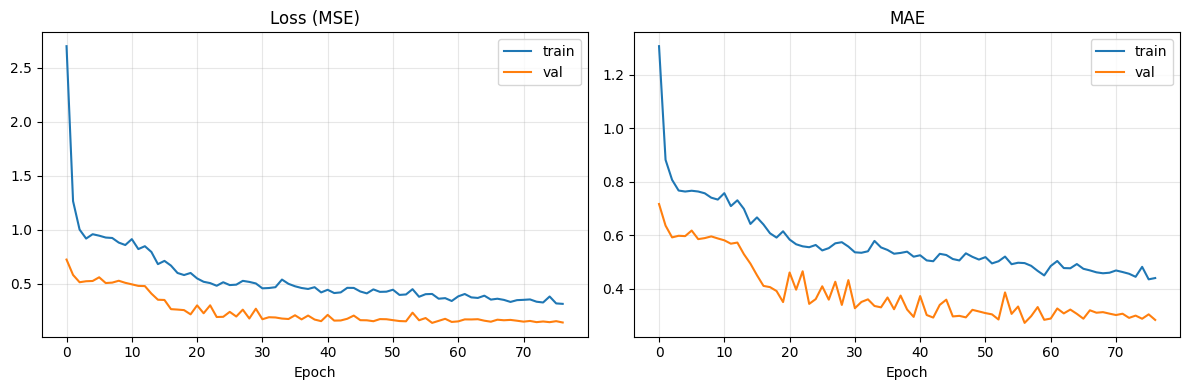

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. 테스트셋 평가

In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = model.predict([X_seq_te, X_mat_te], verbose=0).ravel()

r2   = r2_score(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
mae  = mean_absolute_error(y_te, y_pred)

print('=== Transformer Test 성능 (log10(N_f) 기준) ===')
print(f'R²   : {r2:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')

=== Transformer Test 성능 (log10(N_f) 기준) ===
R²   : 0.7141
RMSE : 0.4251
MAE  : 0.3353


## 13. 예측 vs 실제 그래프

/tmp/ipykernel_8100/3353856438.py:16: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8100/3353856438.py:16: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8100/3353856438.py:16: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8100/3353856438.py:16: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/d

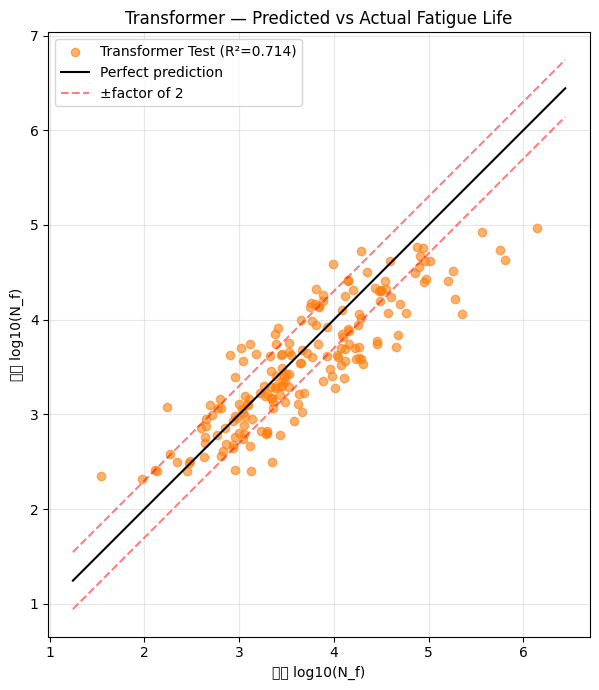

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, y_pred, alpha=0.6, color='C1', label=f'Transformer Test (R²={r2:.3f})')

lo = min(y_te.min(), y_pred.min()) - 0.3
hi = max(y_te.max(), y_pred.max()) + 0.3
ax.plot([lo, hi], [lo, hi], 'k-', label='Perfect prediction')
ax.plot([lo, hi], [lo + np.log10(2), hi + np.log10(2)], 'r--', alpha=0.5, label='±factor of 2')
ax.plot([lo, hi], [lo - np.log10(2), hi - np.log10(2)], 'r--', alpha=0.5)

ax.set_xlabel('실제 log10(N_f)')
ax.set_ylabel('예측 log10(N_f)')
ax.set_title('Transformer — Predicted vs Actual Fatigue Life')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 14. RNN 결과와 비교RNN 노트북에서 저장한 결과를 불러와 같은 테스트셋에서 두 모델을 직접 비교한다.

In [ ]:
import pickle

SAVE_DIR = '/content/drive/MyDrive/fatigue_rnn_results'

# RNN 결과 불러오기
rnn_path = os.path.join(SAVE_DIR, 'simple_rnn_result.pkl')
if os.path.exists(rnn_path):
    with open(rnn_path, 'rb') as f:
        rnn_result = pickle.load(f)
    print(f'RNN 결과 로드 완료:')
    print(f'  R²   : {rnn_result["R2"]:.4f}')
    print(f'  RMSE : {rnn_result["RMSE"]:.4f}')
    print(f'  MAE  : {rnn_result["MAE"]:.4f}')
    print(f'  파라미터: {rnn_result["n_params"]:,}')
else:
    print('RNN 결과가 없습니다. RNN 노트북을 먼저 실행하세요.')
    rnn_result = None

print(f'\nTransformer 결과:')
print(f'  R²   : {r2:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  파라미터: {model.count_params():,}')

In [ ]:
# 두 모델을 한 그림에서 비교
if rnn_result is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 왼쪽: 산점도 비교
    axes[0].scatter(rnn_result['y_test_log'], rnn_result['y_pred_log'],
                    alpha=0.5, label=f'SimpleRNN (R²={rnn_result["R2"]:.3f})')
    axes[0].scatter(y_te, y_pred, alpha=0.5, color='C1',
                    label=f'Transformer (R²={r2:.3f})')

    lo = min(min(rnn_result['y_test_log']), y_te.min()) - 0.3
    hi = max(max(rnn_result['y_test_log']), y_te.max()) + 0.3
    axes[0].plot([lo, hi], [lo, hi], 'k-')
    axes[0].plot([lo, hi], [lo + np.log10(2), hi + np.log10(2)], 'r--', alpha=0.5)
    axes[0].plot([lo, hi], [lo - np.log10(2), hi - np.log10(2)], 'r--', alpha=0.5)
    axes[0].set_xlabel('실제 log10(N_f)')
    axes[0].set_ylabel('예측 log10(N_f)')
    axes[0].set_title('RNN vs Transformer — Test set')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_aspect('equal')

    # 오른쪽: 성능 막대 그래프
    metrics_names = ['R²', 'RMSE', 'MAE']
    rnn_vals = [rnn_result['R2'], rnn_result['RMSE'], rnn_result['MAE']]
    tr_vals  = [r2, rmse, mae]

    x = np.arange(len(metrics_names))
    w = 0.35
    axes[1].bar(x - w/2, rnn_vals, w, label='SimpleRNN')
    axes[1].bar(x + w/2, tr_vals,  w, label='Transformer', color='C1')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(metrics_names)
    axes[1].set_title('성능 지표 비교')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    # 값 표시
    for i, (a, b) in enumerate(zip(rnn_vals, tr_vals)):
        axes[1].text(i - w/2, a, f'{a:.3f}', ha='center', va='bottom', fontsize=9)
        axes[1].text(i + w/2, b, f'{b:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # 표 형태로 정리
    comparison = pd.DataFrame({
        'Model':       ['SimpleRNN', 'Transformer'],
        'R²':          [rnn_result['R2'],   r2],
        'RMSE':        [rnn_result['RMSE'], rmse],
        'MAE':         [rnn_result['MAE'],  mae],
        'Parameters':  [rnn_result['n_params'], model.count_params()],
    })
    print('\n', comparison.to_string(index=False))

## 15. (선택) Attention 가중치 시각화Transformer의 장점 중 하나는 **해석 가능성**이다. 모델이 시계열의 어느 부분을 보고 판단했는지 attention map으로 확인할 수 있다.

In [ ]:
# 첫 번째 encoder block의 attention 가중치 추출
# (모델을 다시 정의하기 번거로우니 여기서는 간단한 예시로 보여줌)

import tensorflow.keras.backend as K

# Test sample 하나 골라서 attention 보기
sample_idx = 0
sample_seq = X_seq_te[sample_idx:sample_idx+1]
sample_mat = X_mat_te[sample_idx:sample_idx+1]

# 입력 시계열 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sample_seq[0])
axes[0].set_title(f'Test sample #{sample_idx} 시계열 입력')
axes[0].set_xlabel('Time step')
axes[0].grid(alpha=0.3)

# 실제 vs 예측
pred = model.predict([sample_seq, sample_mat], verbose=0)[0, 0]
actual = y_te[sample_idx]
axes[1].bar(['Actual', 'Predicted'], [actual, pred])
axes[1].set_ylabel('log10(N_f)')
axes[1].set_title(f'실제: {actual:.3f}, 예측: {pred:.3f}')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Attention 가중치를 직접 추출하려면, MultiHeadAttention 레이어에서')
print('return_attention_scores=True 옵션으로 모델을 재구성해야 한다 (학생 과제).')

---## 학생 토의 과제1. **두 모델의 R²와 RMSE는 얼마나 차이 나는가?** 본 데이터처럼 시퀀스가 짧으면(T=50) 일반적으로 두 모델이 비슷한 성능을 낸다. 그 이유는?2. **파라미터 효율**: Transformer가 RNN보다 파라미터가 많다면, 성능 향상이 그만큼 가치가 있는가? "성능 / 파라미터" 비율을 계산해보자.3. **시퀀스 길이의 영향**: `SEQ_LEN`을 500으로 늘리면 어느 모델이 더 유리할까? 한 번 실험해보고 결과를 해석하라.4. **Transformer 하이퍼파라미터**: `d_model`, `n_heads`, `n_blocks`를 바꾸면 어떻게 되는가? 작은 데이터(<1500개)에서는 큰 모델이 오히려 과적합될 수 있음에 주의.5. **응용**: 본 방법론을 원자력 압력용기강(SA-508 등)의 다축 피로 수명 예측에 적용하려면 어떤 추가 데이터가 필요할까? 조사 결과를 토의하라.6. **Attention 해석 (심화 과제)**: `MultiHeadAttention` 레이어에서 `return_attention_scores=True`로 모델을 재구성하여, 피로 사이클의 어느 위치(peak strain, valley 등)에 모델이 가장 큰 attention을 주는지 시각화하라.## 정리- 본 실습으로 **같은 데이터·전처리·평가**에서 RNN과 Transformer를 직접 비교했다- 작은 시계열 데이터에서는 두 모델이 유사한 성능을 보이는 것이 일반적- 시퀀스가 길어지거나 데이터가 많아질수록 Transformer의 우위가 커진다- 원자력 재료공학에서 다축 피로 수명 예측은 압력용기, 배관, 핵연료 피복관 등 안전성 평가에 직접 응용된다